# Firing rates (KS4)

author: laquitainesteeve@gmail.com

purpose: Validate firing rates from ks4

Tested on Ubuntu 24.04.1 LTS (32 cores, 188 GB RAM, Intel(R) Core(TM) i9-14900K ＠3.2 GHz/5.8 GHz) with RTX 5090 GPU with 40GB VRAM (GPU not needed)

Required resources:

- RAM: 184 GB

## Setup

Prerequisites:

1. Setup "_envs/spikebias.yml_" virtual environment
2. Setup jupyter kernel _$python -m ipykernel install --user --name spikebias --display-name "spikebias"_
3. Download with notebooks/0_download_sortings.ipynb
4. Or Spike sort with: 
    - "_src/pipes/sorting/npx_vivo/10m/ks4.py_" 
    - "_src/pipes/sorting/npx_spont/10m/ks4.py_"
    - "_src/pipes/sorting/npx_evoked/10m/ks4.py_"
    - "_src/pipes/sorting/npx_synth/10m/ks4.py_"

In [34]:
%load_ext autoreload
%autoreload 2
from matplotlib import pyplot as plt
import numpy as np
import os
import warnings
import pandas as pd 

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")

# SET PROJECT PATH

PROJ_PATH = "/home/steeve/steeve/epfl/code/spikebias"
os.chdir(PROJ_PATH)
from src.nodes.utils import get_config, savefig
from src.nodes.validation import firing_rate as fr
from src.nodes.validation.npx_probe import firing_rate as fr_npx

# SETUP EXPERIMENTS

# setup kilosort4 sorting paths
SORTED_PATH_nv = "dataset/01_intermediate/sorting/marques/SortingKS4_10m"
SORTED_PATH_ns = "dataset/01_intermediate/sorting/npx_spont/SortingKS4_10m"
SORTED_PATH_ne = "dataset/01_intermediate/sorting/npx_evoked/SortingKS4_10m"
SORTED_PATH_nb = "dataset/01_intermediate/sorting/buccino/SortingKS4_10m"

# PARAMETERS
SINGLE_UNIT = True
layers = ["L1", "L2/3", "L4", "L5", "L6"]

# SETUP PLOT 

# set lognormal plot parameters
log_x_min = -3.0
log_x_max = 3.0
nbins = 30

# IF you don't want to use the feature, set the value to 1E100
# t_dec = 3600 # seconds until experimenter decides a cell is silent
t_dec = 1^100 # seconds until experimenter decides a cell is silent

cl = dict()
cl["COLOR_NV"] = [0.6, 0.6, 0.6]
cl["COLOR_NS"] = [0.9, 0.14, 0.15]
cl["COLOR_NB"] = [0.22, 0.5, 0.72] # blue
cl["COLOR_NE"] = [1, 0.49, 0] # orange
cl["COLOR_HV"] = "k" # black
cl["COLOR_HS"] = np.array([26, 152, 80]) / 255 # green

# axes
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6  # 5-7 with Nature neuroscience as reference
plt.rcParams["lines.linewidth"] = 0.5 # typically between 0.5 and 1
plt.rcParams["axes.linewidth"] = 0.5 #1
plt.rcParams["axes.spines.top"] = False
plt.rcParams["xtick.major.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["xtick.minor.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["ytick.major.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["ytick.minor.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["xtick.major.size"] = 3.5 * 1.1
plt.rcParams["xtick.minor.size"] = 2 * 1.1
plt.rcParams["ytick.major.size"] = 3.5 * 1.1
plt.rcParams["ytick.minor.size"] = 2 * 1.1

# legend
legend_cfg = {"frameon": False, "handletextpad": 0.5}
tight_layout_cfg = {"pad": 0.001}
LG_FRAMEON = False              # no legend frame

savefig_cfg = {"transparent":True, "dpi": 400}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Get metadata

In [35]:
# get unit metadata
df_nv = fr.get_sorted_unit_meta(SORTED_PATH_nv)
df_ns = fr.get_sorted_unit_meta(SORTED_PATH_ns)
df_ne = fr.get_sorted_unit_meta(SORTED_PATH_ne)
df_nb = fr.get_synth_unit_meta(SORTED_PATH_nb)

# keep units in cortex
df_nv = df_nv[np.isin(df_nv["layer"], ["L1", "L2/3", "L4", "L5", "L6"])]
df_ns = df_ns[np.isin(df_ns["layer"], ["L1", "L2/3", "L4", "L5", "L6"])]
df_ne = df_ne[np.isin(df_ne["layer"], ["L1", "L2/3", "L4", "L5", "L6"])]

# unit-test: check all in cortex
assert all(
    np.isin(np.sort(df_nv["layer"].unique()), ["L1", "L2/3", "L4", "L5", "L6"])
), "nor all in cortex"
assert all(
    np.isin(np.sort(df_ns["layer"].unique()), ["L1", "L2/3", "L4", "L5", "L6"])
), "nor all in cortex"
assert all(
    np.isin(np.sort(df_nv["layer"].unique()), ["L1", "L2/3", "L4", "L5", "L6"])
), "nor all in cortex"

## Curate/or not

- evidence that false positives are low amplitude sorted spikes
- evidence that L1 silico best matches L1 vivo when selecting higher amplitude spikes
- evidence that other layers best match when selecting all spikes

In [36]:
if SINGLE_UNIT:
    df_nv = df_nv[df_nv["kslabel"] == "good"]
    df_ns = df_ns[df_ns["kslabel"] == "good"]
    df_ne = df_ne[df_ne["kslabel"] == "good"]
    df_nb = df_nb[df_nb["kslabel"] == "good"]

## Sorted units total

In [37]:
# reproducible - OK
print("M: total sorted unit:", df_nv.shape[0])
print("NS: total sorted unit:", df_ns.shape[0])
print("E: total sorted unit:", df_ne.shape[0])
print("S: total sorted unit:", df_nb.shape[0])

M: total sorted unit: 96
NS: total sorted unit: 184
E: total sorted unit: 407
S: total sorted unit: 377


## Plot firing rate distributions

In [38]:
layers = ["L1", "L2/3", "L4", "L5", "L6"]
exps = ["M", "NS", "E", "S"]

#### Plot distributions

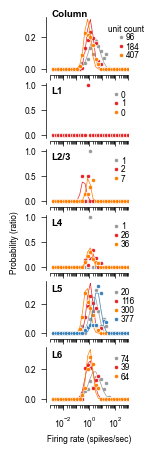

In [43]:
# setup figure
FIGSIZE = (1, 5)

# setup plot
fig, axes = plt.subplots(len(layers) + 1, 1, figsize=FIGSIZE)

# plot
axes, df_hist = fr_npx.plot_fr_by_layer(
    axes, df_nv, df_ns, df_ne, df_nb, layers, log_x_min, log_x_max, nbins, t_dec, cl
)

# save figure
plt.savefig("figures/8_source_data/fig4a/fig4a.svg", bbox_inches="tight", **savefig_cfg)

### Create source dataset

In [40]:
df_hist.to_excel("figures/8_source_data/fig4a/fig4a.xlsx", index=False)
display(df_hist)

,x,y_data,y_fit,layer,experiment,n
0,0.001610,0.0,3.260603e-14,Column,M,96
1,0.002593,0.0,1.289835e-12,Column,M,96
2,0.004175,0.0,3.992184e-11,Column,M,96
3,0.006723,0.0,9.667790e-10,Column,M,96
4,0.010826,0.0,1.831826e-08,Column,M,96
...,...,...,...,...,...,...
546,148.735211,0.0,2.268433e-18,L6,E,64
547,239.502662,0.0,7.275944e-22,L6,E,64
548,385.662042,0.0,1.108934e-25,L6,E,64
549,621.016942,0.0,8.031099e-30,L6,E,64


### Load

In [41]:
# load source dataset
df_hist_loaded = pd.read_excel("figures/8_source_data/fig4a/fig4a.xlsx")

### Re-plot

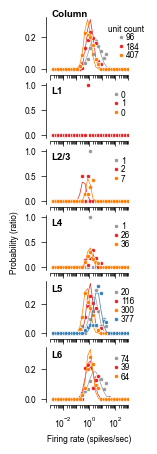

In [ ]:
# setup figure
FIGSIZE = (1, 5)

# setup plot
fig, axes = plt.subplots(len(layers) + 1, 1, figsize=FIGSIZE)

# replot from the loaded source dataset (no recomputation)
axes = fr_npx.plot_fr_by_layer_from_df(axes, df_hist_loaded, layers, cl)